# Level 1 - Task 2: Exploratory Data Analysis (EDA)


**Objective:** Perform exploratory analysis to identify patterns, trends, and summary statistics.

In [2]:
# import library

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load cleaned dataset from Task 1
df = pd.read_csv('cleaned_cafe_sales.csv')

# Verify the data loaded correctly
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


### Summary Statistics
Calculating the mean, median, and standard deviation to understand the distribution of sales.

In [12]:
# Using .describe() provides mean, std, and quartiles for numerical features
numerical_stats = df[['quantity', 'price_per_unit', 'total_spent']].describe()

print("--- Numerical Summary Statistics ---")
print(numerical_stats)

--- Numerical Summary Statistics ---
          quantity  price_per_unit  total_spent
count  9540.000000     9540.000000  9540.000000
mean      3.024109        2.952673     8.924109
std       1.384186        1.243449     5.997956
min       1.000000        1.000000     1.000000
25%       2.000000        2.000000     4.000000
50%       3.000000        3.000000     8.000000
75%       4.000000        4.000000    12.000000
max       5.000000        5.000000    25.000000


In [18]:
# Calculate Mode specifically for 'item' to see the most popular product
popular_item = df['item'].mode()[0]

print(f"Most popular item: {popular_item}")

Most popular item: Juice


**Insight:** The summary statistics reveal the typical transaction size. By comparing the mean and median of total_spent, we can see if the sales data is skewed by very large orders. The mode identifies "Juice"  as the most popular item.

### visualizing distribution

In [9]:
# Set the visual style
sns.set_theme(style="whitegrid")

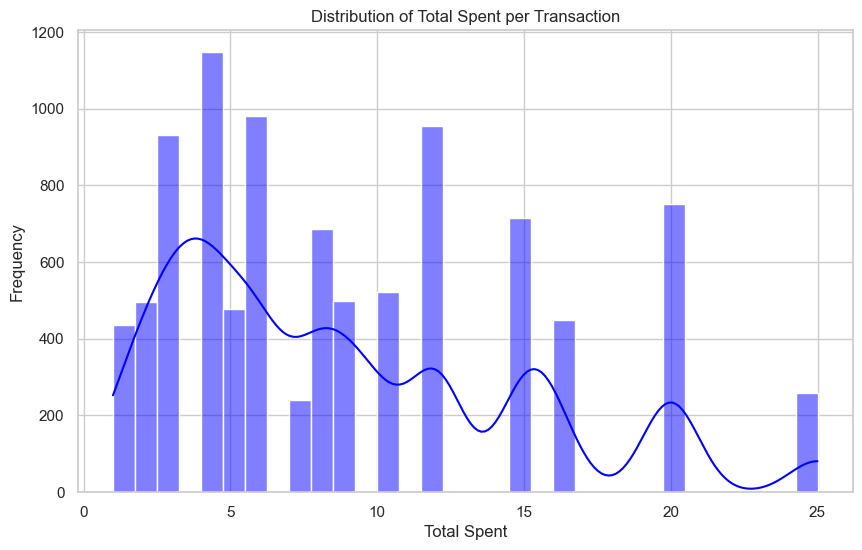

In [10]:
# Histogram: Distribution of Total Spent
plt.figure(figsize=(10, 6))
sns.histplot(df['total_spent'], kde=True, color='blue')
plt.title('Distribution of Total Spent per Transaction')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show() 



**Insight:**The histogram displays a right-skewed distribution, revealing that the cafe’s revenue is primarily driven by high-frequency, small-value transactions concentrated between **4** and **12**. While the peak volume occurs at these lower price points, a "long tail" extending to $25 represents occasional bulk orders. This pattern suggests a stable customer base for individual items, with clear opportunities to boost the average transaction value through bundled offerings or upselling strategies. 

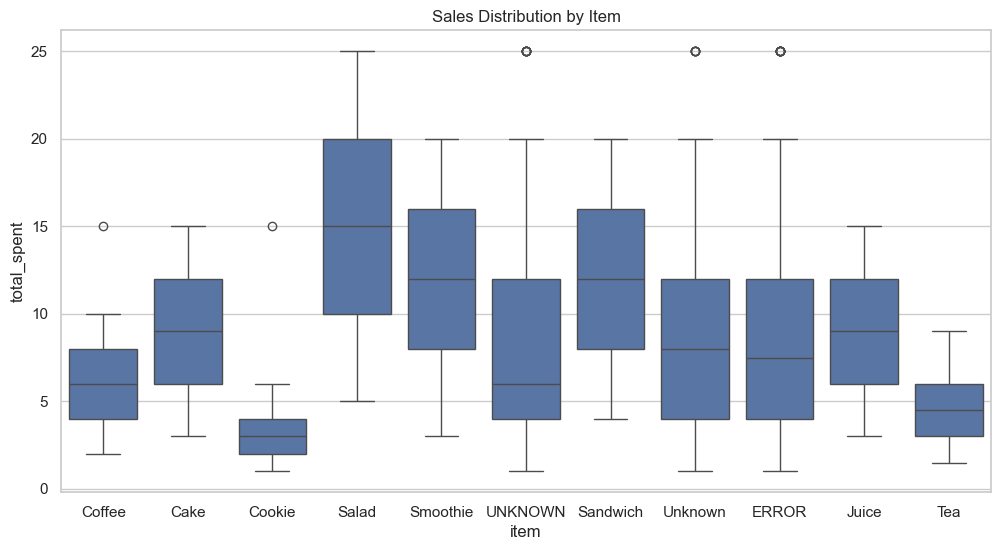

In [11]:
# Boxplot: Item vs Total Spent to see outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='item', y='total_spent')
plt.title('Sales Distribution by Item')
plt.show()

**Insight:** This boxplot highlights the price variance for each item. Items with a "taller" box have more varied transaction totals. Any dots above the whiskers represent outliers, unusually large bulk orders that significantly exceed typical individual sales

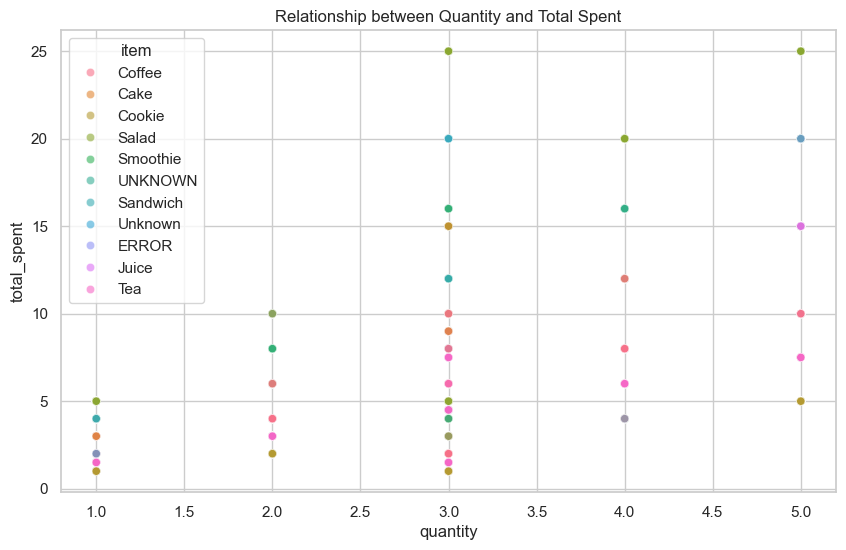

In [21]:
# Scatter Plot: Quantity vs Total Spent
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='quantity', y='total_spent', hue='item', alpha=0.6)
plt.title('Relationship between Quantity and Total Spent')
plt.show()

**Insight:** The scatter plot confirms a direct relationship between quantity and revenue. While Juice drives the most frequent transactions, the highest individual sales are achieved when customers purchase 5 units of premium items like Cake or Salad. This visual proves that increasing the "units per transaction" is a viable strategy for boosting cafe revenue.

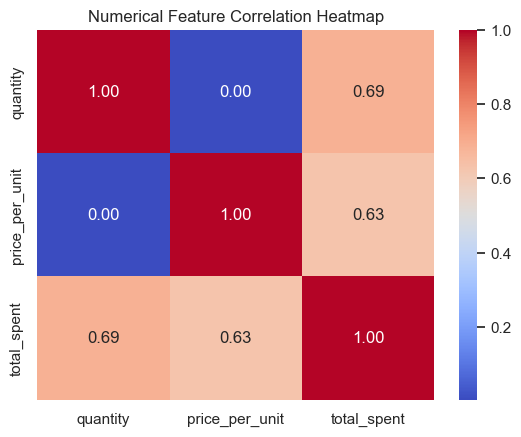

In [20]:
# Calculating and visualizing correlations 
correlation_matrix = df[['quantity', 'price_per_unit', 'total_spent']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

**Insight:** The heatmap provides a mathematical look at relationships. A high correlation (**0.69**) between quantity and total_spent is expected, while the correlation between price_per_unit and total_spentis **0.63**. This proves that the number of items bought (quantity) has a slightly stronger impact on your revenue than the price of the item itself.

## Final Summary

**Top Performer:** Juice is the most frequently purchased item, making it the volume leader for the cafe.

**Revenue Dynamics:** There is a strong positive correlation (0.69) between quantity and total spending. This suggests that customers buying multiple items are the primary drivers of high-value transactions.

**Spending Patterns:** The histogram displays a right-skewed distribution, revealing that the cafe’s revenue is primarily driven by high-frequency, small-value transactions concentrated between **4** and **12**.
.